9) Create a data frame showing the number of drugs that are approved, withdrawn, in the experimental/investigational phase, and approved for veterinary use. Present this data. Provide the number of approved drugs that have not been withdrawn.

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt

# Define the file path and namespace
file_path = 'drugbank_partial.xml'
namespace = {'drugbank': 'http://www.drugbank.ca'}
group_dict = {}
approved_not_withdrawn = 0

# Parse the XML file and extract relevant information
for event, elem in ET.iterparse(file_path, events=('start', 'end')):
    if elem.tag == f"{{{namespace['drugbank']}}}drug" and event == 'end':
        approved = False
        withdrawn = False
        # Check the group of each drug
        for group in elem.findall('.//drugbank:group', namespace):
            if group.text == 'approved':
                approved = True
            if group.text == 'withdrawn':
                withdrawn = True
            if group.text not in group_dict:
                group_dict[group.text] = 1
            else:
                group_dict[group.text] += 1

            if approved and not withdrawn:
                approved_not_withdrawn += 1
        elem.clear()

# Print the number of approved drugs that were not withdrawn
print(f'Number of approved drugs that were not withdrawn: {approved_not_withdrawn}')
# Create a DataFrame from the extracted data
df = pd.DataFrame([group_dict])
df

Number of approved drugs that were not withdrawn: 157


,approved,withdrawn,investigational,vet_approved,experimental
0,98,10,54,4,3


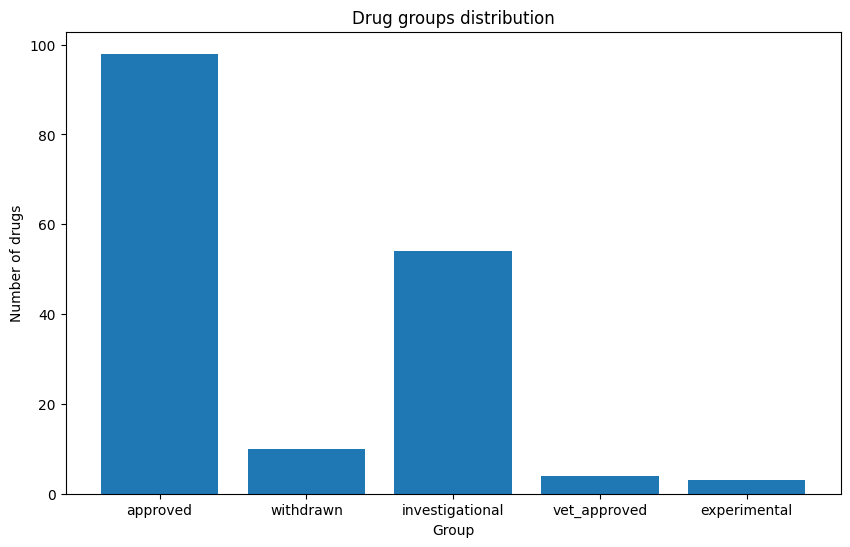

In [2]:
# Plot a bar chart of the drug groups distribution
plt.figure(figsize=(10, 6))
plt.bar(df.columns, df.iloc[0])
plt.title('Drug groups distribution')
plt.xlabel('Group')
plt.ylabel('Number of drugs')
plt.show()